# Epilepsy - training set

Exploration only. Official UCR/UEA partition, training split; the test split stays untouched.

Loaded through `src.dataio` so this sees exactly the arrays the pipeline sees.

In [1]:
import sys
from pathlib import Path

ROOT = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "src" / "config.yaml").exists())
for p in (str(ROOT), str(ROOT / "eda")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np

from plots import plot_channels, plot_class_examples
from src.dataio.splits import class_order, load_split
from src.utils.config import load_config

DATASET = "Epilepsy"
cfg = load_config()
print(ROOT)

c:\Users\Bruger\Documents\Repos\PhD-Courses\Deep learning for time-series\Assignment 4


## Load

In [2]:
X_train, y_train = load_split(cfg, DATASET, "TRAIN")
names = class_order(cfg, DATASET)
X_train.shape, y_train.shape

((137, 3, 206), (137,))

## Shape

In [3]:
n_series, n_channels, n_timestamps = X_train.shape

print(f"series      {n_series}")
print(f"channels    {n_channels}")
print(f"timestamps  {n_timestamps}")

classes, counts = np.unique(y_train, return_counts=True)
print()
print(f"classes     {len(classes)}")
for cls, count in zip(classes, counts):
    print(f"  {names[cls]:<12} {count:5d}  ({count / n_series:.1%})")

print()
print(f"missing     {int(np.isnan(X_train).sum())}")

series      137
channels    3
timestamps  206

classes     4
  EPILEPSY        34  (24.8%)
  WALKING         37  (27.0%)
  RUNNING         36  (26.3%)
  SAWING          30  (21.9%)

missing     0


## One series per class

Small multiples on shared axes, so panels are directly comparable. The example index is drawn with a fixed seed.

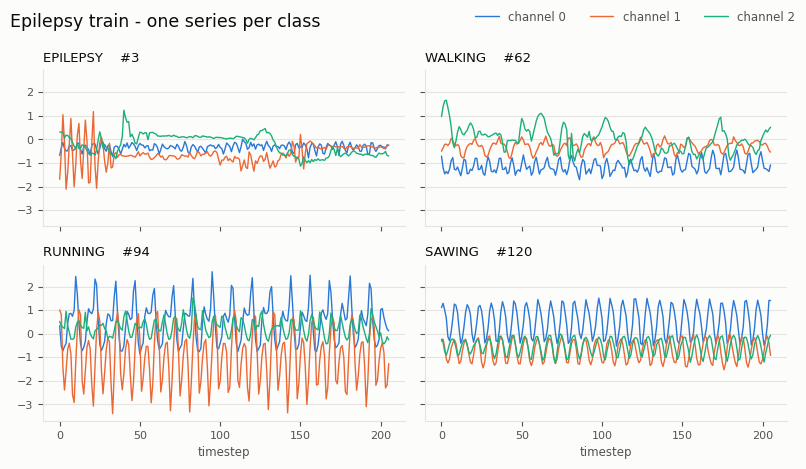

In [4]:
fig = plot_class_examples(X_train, y_train, names, f"{DATASET} train - one series per class")

## Channels

For a multivariate dataset, every channel of a single example, faceted.

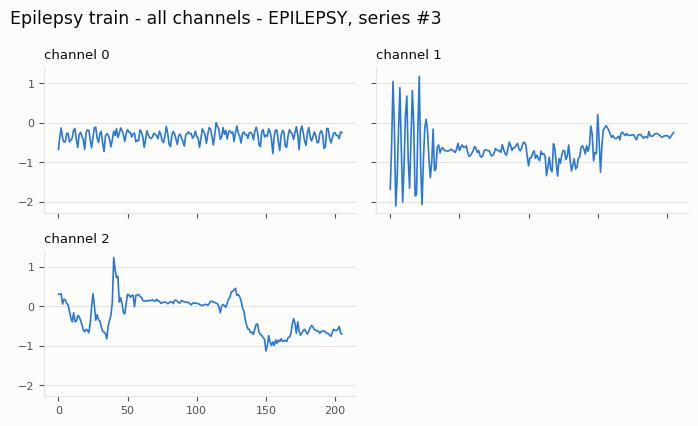

In [5]:
if n_channels > 1:
    fig = plot_channels(X_train, y_train, names, 0, f"{DATASET} train - all channels")
else:
    print(f"{DATASET} is univariate; the figure above already shows its only channel.")